# Boosting

Boosting is an ensemble learning technique that combines multiple weak learners sequentially to create a strong learner.

The key idea is:

> Train models one after another, where each new model focuses more on the mistakes made by the previous models.

In this notebook, we will study:

- What is Boosting?
- Why Boosting works
- Weak learners and strong learners
- Sequential learning
- AdaBoost
- AdaBoost mathematics
- Gradient Boosting
- Gradient Boosting mathematics
- Learning rate
- Number of estimators
- Tree depth
- XGBoost
- LightGBM
- CatBoost
- Boosting for classification
- Boosting for regression
- Hyperparameter tuning
- Feature importance
- Advantages and disadvantages
- Bagging vs Boosting
- Practical comparison of ensemble models

## What is Boosting?

Boosting is an ensemble learning method where weak learners are trained sequentially.

Each new learner tries to improve the mistakes of the previous ensemble.

Instead of building many independent models, Boosting builds models one after another.

The general idea is:

$$
h_1(x) \rightarrow h_2(x) \rightarrow h_3(x) \rightarrow \cdots \rightarrow h_M(x)
$$

where:

- $h_m(x)$ is the $m$-th weak learner
- $M$ is the total number of learners

The final model combines all weak learners:

$$
F(x) = \sum_{m=1}^{M} \alpha_m h_m(x)
$$

where $\alpha_m$ represents the contribution of learner $m$.

The main objective is to convert many weak learners into a strong predictive model.

## Weak Learner

A weak learner is a model that performs only slightly better than random guessing.

For example, a shallow decision tree can act as a weak learner.

A decision tree with:

$$
\text{max\_depth} = 1
$$

is called a decision stump.

A decision stump makes a very simple decision:

```text
Feature X > threshold?
        |
     /     \
   Yes      No

A single weak learner may not be very powerful.

However, Boosting combines many weak learners to create a much stronger model.


---


## Why Do We Need Boosting?

A single model may make many prediction errors.

Instead of trying to create one extremely complex model, Boosting builds a sequence of simple models.

The process is approximately:

1. Train a weak learner.
2. Find where it makes mistakes.
3. Give more attention to difficult observations.
4. Train another weak learner.
5. Repeat the process.
6. Combine all learners.

Therefore, later learners focus on the difficult examples that earlier learners could not handle well.

## Bagging vs Boosting

Bagging and Boosting are both ensemble learning techniques, but they work differently.

### Bagging

Models are trained independently.

$$
h_1(x), h_2(x), h_3(x), \ldots, h_M(x)
$$

The models can be trained in parallel.

Example:

- Random Forest

### Boosting

Models are trained sequentially.

$$
h_1(x) \rightarrow h_2(x) \rightarrow h_3(x) \rightarrow \cdots
$$

Each new learner tries to correct previous errors.

Examples:

- AdaBoost
- Gradient Boosting
- XGBoost
- LightGBM
- CatBoost

### Main Difference

Bagging mainly reduces variance.

Boosting mainly reduces bias while controlling variance through regularization.

## Sequential Learning

The most important characteristic of Boosting is sequential learning.

Suppose we have three learners:

$$
h_1,\ h_2,\ h_3
$$

The process is:

$$
h_1
$$

↓

Identify errors

↓

$$
h_2
$$

↓

Focus on remaining errors

↓

$$
h_3
$$

↓

Combine all models

The final prediction depends on the contributions of all learners.

This is different from Random Forest, where trees are generally trained independently.

## Basic Boosting Idea

Suppose the first learner produces:

$$
F_1(x) = h_1(x)
$$

The second learner tries to improve the current model:

$$
F_2(x) = F_1(x) + \alpha_2 h_2(x)
$$

The third learner further improves it:

$$
F_3(x) = F_2(x) + \alpha_3 h_3(x)
$$

Therefore:

$$
F_M(x) =
\sum_{m=1}^{M} \alpha_m h_m(x)
$$

The final model is an additive combination of weak learners.

## Important Boosting Algorithms

The major Boosting algorithms are:

### 1. AdaBoost

Adaptive Boosting changes the importance of training samples.

### 2. Gradient Boosting

Gradient Boosting trains new models to reduce the current loss.

### 3. XGBoost

An optimized and regularized implementation of gradient boosting.

### 4. LightGBM

A highly efficient gradient boosting framework designed for large datasets.

### 5. CatBoost

A gradient boosting algorithm particularly strong when working with categorical features.

We will first understand AdaBoost and Gradient Boosting because they explain the fundamental ideas behind modern Boosting algorithms.

# AdaBoost

AdaBoost stands for:

**Adaptive Boosting**

The key idea is to assign different weights to training observations.

Initially, every observation has equal importance.

After training a weak learner:

- Correctly classified observations receive less attention.
- Misclassified observations receive more attention.

The next learner therefore focuses more strongly on difficult observations.

## AdaBoost Algorithm

Suppose we have training observations:

$$
(x_1,y_1), (x_2,y_2), \ldots, (x_n,y_n)
$$

### Step 1

Initialize equal weights:

$$
w_i = \frac{1}{n}
$$

### Step 2

Train a weak learner.

### Step 3

Calculate its weighted error.

$$
\epsilon_m =
\sum_{i=1}^{n}
w_i I(y_i \neq h_m(x_i))
$$

### Step 4

Calculate the learner's weight:

$$
\alpha_m =
\frac{1}{2}
\ln
\left(
\frac{1-\epsilon_m}{\epsilon_m}
\right)
$$

### Step 5

Increase the weights of incorrectly classified observations.

### Step 6

Repeat for the next learner.

### Step 7

Combine all learners.

$$
H(x) =
\operatorname{sign}
\left(
\sum_{m=1}^{M}
\alpha_m h_m(x)
\right)
$$

## AdaBoost Intuition

Imagine that a dataset contains 100 observations.

Initially:

$$
w_i = 0.01
$$

for every observation.

Suppose the first weak learner incorrectly classifies 10 observations.

AdaBoost increases the importance of those difficult observations.

The next learner therefore pays more attention to them.

After several iterations:

```text
Learner 1
   ↓
Find mistakes
   ↓
Increase difficult examples
   ↓
Learner 2
   ↓
Find remaining mistakes
   ↓
Increase difficult examples
   ↓
Learner 3
   ↓
...

This adaptive process is the core idea behind AdaBoost.


---

# 12. AdaBoost Classification


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_classes=2,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((800, 10), (200, 10))

## Train AdaBoost

We will use decision stumps as weak learners.

A decision stump is simply a decision tree with:

$$
\text{max\_depth}=1
$$

In [3]:
base_model = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

ada_model = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

ada_model.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...ndom_state=42)
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None


In [4]:
y_pred = ada_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("AdaBoost Accuracy:", accuracy)

AdaBoost Accuracy: 0.79


In [5]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.71      0.77       100
           1       0.75      0.87      0.81       100

    accuracy                           0.79       200
   macro avg       0.80      0.79      0.79       200
weighted avg       0.80      0.79      0.79       200



## Number of Estimators

`n_estimators` controls how many weak learners are added to the ensemble.

For example:

$$
M = 10
$$

means 10 weak learners.

While:

$$
M = 500
$$

means 500 weak learners.

Increasing the number of estimators can improve performance, but too many learners may increase training time and can contribute to overfitting.

Common values:

```text
50
100
200
500

In [6]:
estimators = [10, 25, 50, 100, 200, 300]

train_scores = []
test_scores = []

for n in estimators:
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=1,
            random_state=42
        ),
        n_estimators=n,
        learning_rate=0.5,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

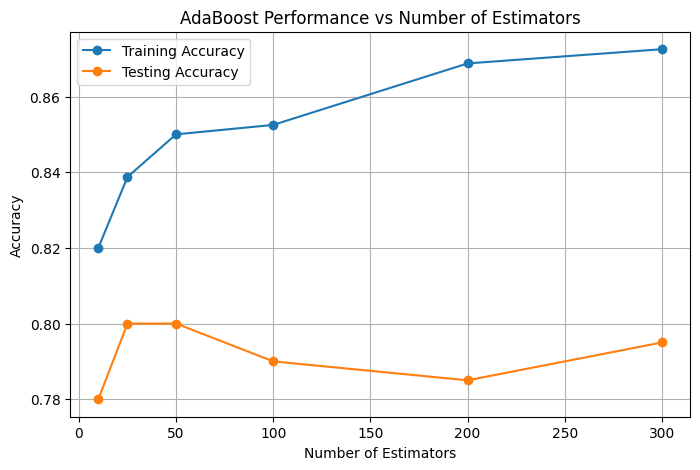

In [7]:
plt.figure(figsize=(8, 5))

plt.plot(
    estimators,
    train_scores,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    estimators,
    test_scores,
    marker="o",
    label="Testing Accuracy"
)

plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("AdaBoost Performance vs Number of Estimators")

plt.legend()
plt.grid()

plt.show()

## Learning Rate

The learning rate controls how strongly each new learner contributes to the final model.

The additive model can be written as:

$$
F_m(x)
=
F_{m-1}(x)
+
\eta \alpha_m h_m(x)
$$

where:

$$
\eta = \text{learning rate}
$$

A smaller learning rate means that each learner makes a smaller contribution.

Therefore, we often need more estimators when using a smaller learning rate.

There is usually a trade-off:

$$
\text{Lower learning rate}
\Rightarrow
\text{More estimators}
$$

A smaller learning rate can improve generalization when combined with a sufficient number of estimators.

## Learning Rate Experiment

In [8]:
learning_rates = [0.01, 0.05, 0.1, 0.5, 1.0]

scores = []

for lr in learning_rates:
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=1,
            random_state=42
        ),
        n_estimators=200,
        learning_rate=lr,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    scores.append(model.score(X_test, y_test))

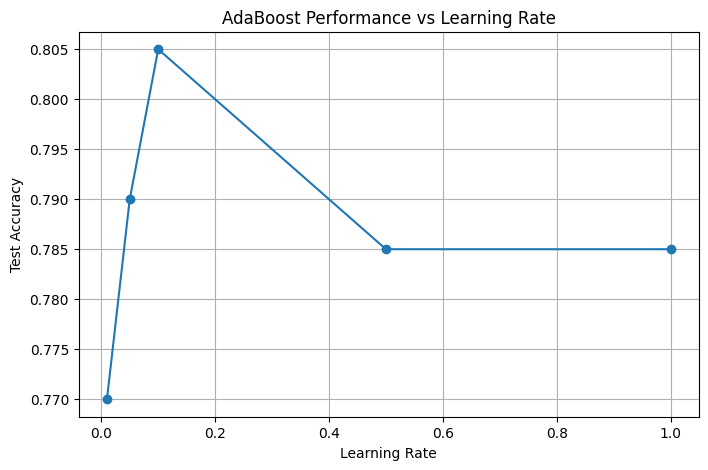

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    learning_rates,
    scores,
    marker="o"
)

plt.xlabel("Learning Rate")
plt.ylabel("Test Accuracy")
plt.title("AdaBoost Performance vs Learning Rate")

plt.grid()

plt.show()

# Gradient Boosting

Gradient Boosting is another important Boosting algorithm.

Instead of explicitly increasing the weight of incorrectly classified observations like AdaBoost, Gradient Boosting trains each new learner to predict the errors or residuals of the current model.

The general idea is:

$$
\text{Current Model}
\rightarrow
\text{Calculate Errors}
\rightarrow
\text{Train New Model on Errors}
\rightarrow
\text{Update Model}
$$

The process continues for many iterations.

## Gradient Boosting for Regression

Suppose the target is:

$$
y_i
$$

The initial prediction may be:

$$
F_0(x)
$$

For squared-error loss, the residual is:

$$
r_i =
y_i - F_0(x_i)
$$

A new weak learner is trained to predict these residuals.

Then:

$$
F_1(x)
=
F_0(x)
+
\eta h_1(x)
$$

The process continues:

$$
F_m(x)
=
F_{m-1}(x)
+
\eta h_m(x)
$$

where:

- $h_m(x)$ is the new weak learner
- $\eta$ is the learning rate

Therefore, each new tree attempts to correct the errors made by the current ensemble.

## Gradient Boosting Regression Example

In [10]:
from sklearn.datasets import make_regression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [11]:
X_reg, y_reg = make_regression(
    n_samples=1000,
    n_features=8,
    n_informative=6,
    noise=20,
    random_state=42
)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [12]:
gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train_reg, y_train_reg)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [13]:
y_pred_reg = gbr.predict(X_test_reg)

mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_reg, y_pred_reg)

print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MSE: 2529.3108586853004
RMSE: 50.29225446015818
R²: 0.8905516820176667


## Actual vs Predicted

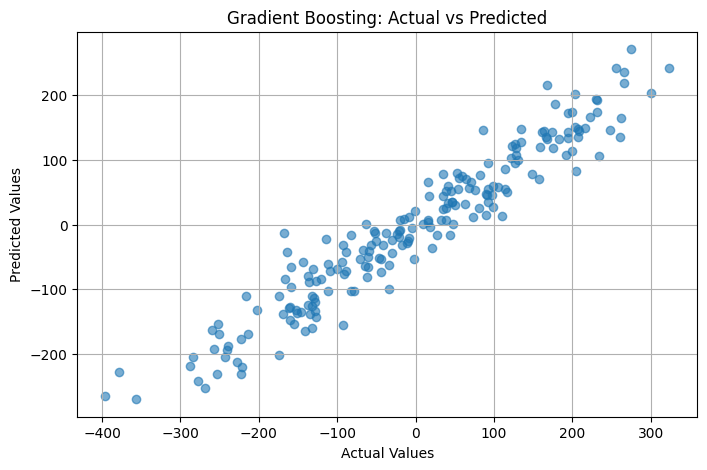

In [14]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test_reg,
    y_pred_reg,
    alpha=0.6
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Gradient Boosting: Actual vs Predicted")

plt.grid()

plt.show()

## Gradient Boosting Classification

Gradient Boosting can also be used for classification.

Instead of directly predicting the class label, the algorithm optimizes a classification loss function.

For binary classification, a common loss is log loss:

$$
L(y,p)
=
-
\left[
y\log(p)
+
(1-y)\log(1-p)
\right]
$$

The boosting process attempts to minimize the overall loss.

Gradient Boosting is therefore a general optimization framework rather than simply a technique for fitting residuals.

In [15]:
from sklearn.ensemble import GradientBoostingClassifier

In [16]:
gb_classifier = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_classifier.fit(X_train, y_train)

gb_pred = gb_classifier.predict(X_test)

print(
    "Gradient Boosting Accuracy:",
    accuracy_score(y_test, gb_pred)
)

Gradient Boosting Accuracy: 0.87


## Important Gradient Boosting Hyperparameters

### `n_estimators`

Number of boosting stages.

Higher values increase model capacity.

### `learning_rate`

Controls the contribution of each learner.

Smaller values usually require more estimators.

### `max_depth`

Controls the complexity of individual trees.

Higher depth:

- More complex trees
- More interactions
- Higher risk of overfitting

### `subsample`

Controls the fraction of training samples used for each boosting stage.

Values below 1.0 introduce randomness and can reduce variance.

### `min_samples_split`

Minimum number of samples required to split a node.

### `min_samples_leaf`

Minimum number of samples in a leaf.

These parameters control the bias-variance trade-off.

## Learning Rate vs Number of Estimators

Learning rate and number of estimators are strongly connected.

A common relationship is:

$$
\text{Smaller learning rate}
\Rightarrow
\text{More estimators}
$$

For example:

```text
Learning Rate = 0.1
Estimators    = 100

Learning Rate = 0.05
Estimators    = 200

Learning Rate = 0.01
Estimators    = 1000

These are only illustrative values.

The best combination depends on the dataset.

The goal is to find a combination that gives strong validation performance without unnecessary complexity.


---

# 23. Gradient Boosting Training Curve



In [18]:
model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

train_scores = []
test_scores = []

for pred_train, pred_test in zip(
    model.staged_predict(X_train),
    model.staged_predict(X_test)
):
    train_scores.append(accuracy_score(y_train, pred_train))
    test_scores.append(accuracy_score(y_test, pred_test))

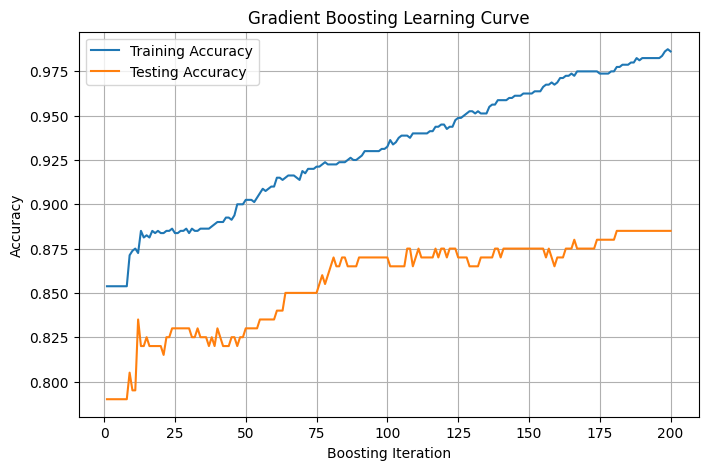

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(train_scores) + 1),
    train_scores,
    label="Training Accuracy"
)

plt.plot(
    range(1, len(test_scores) + 1),
    test_scores,
    label="Testing Accuracy"
)

plt.xlabel("Boosting Iteration")
plt.ylabel("Accuracy")
plt.title("Gradient Boosting Learning Curve")

plt.legend()
plt.grid()

plt.show()

## Feature Importance

Tree-based Boosting models can estimate feature importance.

A feature importance score indicates how much a feature contributed to reducing impurity or loss across the ensemble.

The importance values are typically normalized:

$$
\sum_{j=1}^{d} I_j = 1
$$

where $I_j$ is the importance of feature $j$.

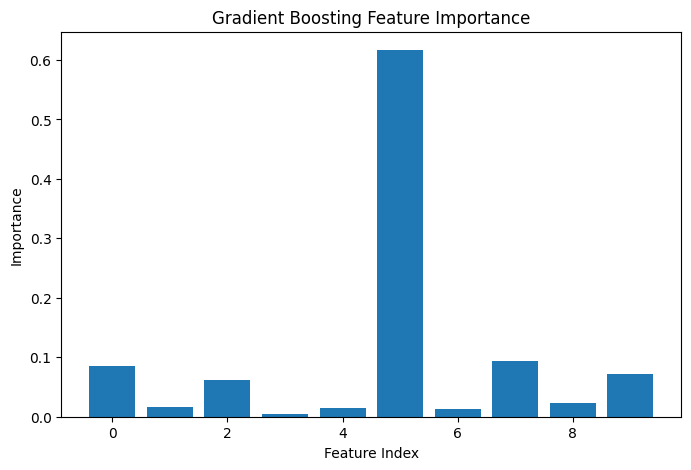

In [20]:
importances = gb_classifier.feature_importances_

plt.figure(figsize=(8, 5))

plt.bar(
    range(len(importances)),
    importances
)

plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.title("Gradient Boosting Feature Importance")

plt.show()

# XGBoost

XGBoost stands for:

**Extreme Gradient Boosting**

It is a highly optimized implementation of gradient boosting.

Important characteristics include:

- Regularization
- Efficient tree construction
- Parallel computation
- Missing-value handling
- Shrinkage through learning rate
- Row and feature subsampling
- Strong performance on tabular datasets

XGBoost became extremely popular in machine learning competitions and practical machine learning applications.

The core idea remains gradient boosting, but the implementation includes several improvements designed to improve speed, scalability, and generalization.

## XGBoost Objective Function

XGBoost minimizes an objective consisting of:

$$
\text{Objective}
=
\text{Training Loss}
+
\text{Regularization}
$$

More formally:

$$
\mathcal{L}
=
\sum_i l(y_i,\hat{y}_i)
+
\sum_k \Omega(f_k)
$$

where:

- $l$ is the training loss
- $f_k$ is the $k$-th tree
- $\Omega(f_k)$ controls model complexity

This regularization helps prevent overly complex trees and improves generalization.

# Install XGBoost if necessary:
# pip install xgboost

In [23]:
from xgboost import XGBClassifier

In [24]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print(
    "XGBoost Accuracy:",
    accuracy_score(y_test, xgb_pred)
)

XGBoost Accuracy: 0.88


# LightGBM

LightGBM is another gradient boosting framework developed for efficiency and scalability.

Important characteristics:

- Fast training
- Low memory usage
- Good performance on large tabular datasets
- Histogram-based learning
- Leaf-wise tree growth

One important difference is that LightGBM commonly uses leaf-wise tree growth rather than level-wise tree growth.

Leaf-wise growth can achieve lower loss efficiently, but it can also overfit on small datasets if tree complexity is not controlled.

# CatBoost

CatBoost is a gradient boosting algorithm designed particularly to work well with categorical features.

Important characteristics:

- Strong handling of categorical variables
- Reduced need for extensive preprocessing
- Good default performance
- Supports numerical and categorical features
- Useful for datasets containing many categorical columns

CatBoost is especially useful when categorical variables are an important part of the dataset.

## AdaBoost vs Gradient Boosting

| Property | AdaBoost | Gradient Boosting |
|---|---|---|
| Main idea | Reweight observations | Fit negative gradients/residuals |
| Learning | Sequential | Sequential |
| Typical learner | Shallow trees | Decision trees |
| Loss optimization | Adaptive weighting | Gradient-based optimization |
| Classification | Yes | Yes |
| Regression | Yes | Yes |
| Sensitivity to noise | Relatively high | Can also be sensitive |
| Modern extensions | Less dominant | XGBoost, LightGBM, CatBoost |

Both methods build models sequentially, but they use different mechanisms to improve the ensemble.

## Bagging vs Boosting vs Random Forest

| Property | Bagging | Random Forest | Boosting |
|---|---|---|---|
| Training | Parallel | Parallel | Sequential |
| Main goal | Reduce variance | Reduce variance | Reduce bias + improve accuracy |
| Trees independent? | Yes | Yes | No |
| Random sampling | Usually | Yes | Depends on algorithm |
| Error correction | No | No | Yes |
| Overfitting resistance | High | High | Depends on regularization |
| Training speed | Usually fast | Usually fast | Usually slower |
| Examples | Bagging | Random Forest | AdaBoost, GBM, XGBoost |

The key conceptual distinction is:

**Bagging:** build many independent models.

**Boosting:** build models that sequentially improve the existing ensemble.

## Boosting and the Bias-Variance Trade-off

Recall:

$$
\text{Expected Test Error}
\approx
\text{Bias}^2
+
\text{Variance}
+
\text{Irreducible Noise}
$$

Boosting often starts with simple, high-bias learners.

By adding learners sequentially, the model becomes increasingly expressive.

Therefore:

$$
\text{Boosting}
\rightarrow
\text{Reduce Bias}
$$

However, excessive model complexity can increase variance.

Important parameters such as:

- learning rate
- number of estimators
- tree depth
- subsampling
- regularization

help control this trade-off.

## Overfitting in Boosting

Boosting can overfit if the model becomes excessively complex.

Common causes:

- Too many estimators
- Very deep trees
- High learning rate
- Insufficient regularization
- Small datasets
- Noisy features
- Noisy labels

Ways to reduce overfitting:

1. Reduce tree depth.
2. Reduce learning rate.
3. Use appropriate regularization.
4. Use subsampling.
5. Use early stopping.
6. Use cross-validation.
7. Remove noisy or irrelevant features.

## Early Stopping

Early stopping stops training when validation performance stops improving.

Suppose validation loss behaves like:

```text
Iteration
1       ↓
10      ↓
20      ↓
30      ↓
40      ↓
50      ↓
60      ↑
70      ↑

The best model may occur around iteration 50.

Instead of continuing to train unnecessary trees, we stop training.

Conceptually:

$$ m^* = \arg\min_m L_{\text{validation}}(m) $$

where $m^*$ is the best boosting iteration.

Early stopping is an important practical technique for controlling overfitting.

---

# 35. Boosting on a Simple Dataset

In [25]:
from sklearn.datasets import make_moons

X_moon, y_moon = make_moons(
    n_samples=1000,
    noise=0.25,
    random_state=42
)

X_train_moon, X_test_moon, y_train_moon, y_test_moon = train_test_split(
    X_moon,
    y_moon,
    test_size=0.2,
    random_state=42,
    stratify=y_moon
)

In [26]:
boost_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=42
)

boost_model.fit(
    X_train_moon,
    y_train_moon
)

print(
    "Test Accuracy:",
    boost_model.score(
        X_test_moon,
        y_test_moon
    )
)

Test Accuracy: 0.965


## 36. Decision Boundary

<Figure size 800x600 with 0 Axes>

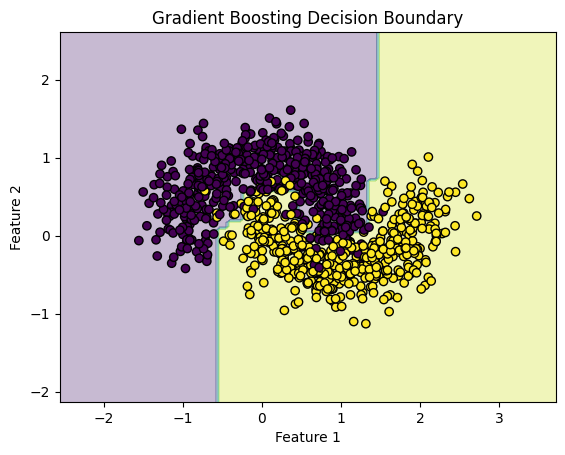

In [27]:
from sklearn.inspection import DecisionBoundaryDisplay

plt.figure(figsize=(8, 6))

DecisionBoundaryDisplay.from_estimator(
    boost_model,
    X_moon,
    response_method="predict",
    alpha=0.3
)

plt.scatter(
    X_moon[:, 0],
    X_moon[:, 1],
    c=y_moon,
    edgecolor="k"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Gradient Boosting Decision Boundary")

plt.show()

## Comparing Ensemble Models

We will compare:

- Decision Tree
- Random Forest
- AdaBoost
- Gradient Boosting
- XGBoost

The goal is not simply to find the model with the highest score.

We should consider:

- Accuracy
- Generalization
- Training time
- Interpretability
- Memory usage
- Dataset size
- Feature types
- Hyperparameter sensitivity

In [28]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [29]:
models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    
    "AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=1,
            random_state=42
        ),
        n_estimators=100,
        learning_rate=0.5,
        random_state=42
    ),
    
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    )
}

In [30]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    
    results[name] = accuracy_score(
        y_test,
        predictions
    )

results

{'Decision Tree': 0.845,
 'Random Forest': 0.895,
 'AdaBoost': 0.79,
 'Gradient Boosting': 0.87,
 'XGBoost': 0.88}

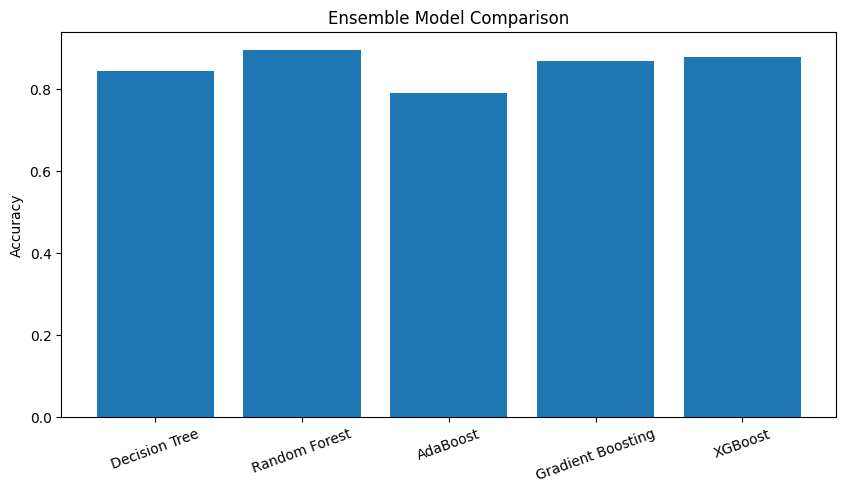

In [31]:
plt.figure(figsize=(10, 5))

plt.bar(
    results.keys(),
    results.values()
)

plt.ylabel("Accuracy")
plt.title("Ensemble Model Comparison")

plt.xticks(rotation=20)

plt.show()

## When Should You Use Boosting?

Boosting is especially useful when:

- You have structured/tabular data.
- You need strong predictive performance.
- Relationships between features and target are nonlinear.
- Feature interactions are important.
- You want a powerful model without manually engineering every interaction.
- Dataset size is moderate or large.
- You can afford hyperparameter tuning.

Boosting models are often excellent choices for:

- Classification
- Regression
- Ranking
- Tabular prediction
- Credit scoring
- Fraud detection
- Customer churn prediction
- Demand forecasting
- Risk modeling

## When Should You Avoid Boosting?

Boosting may not be the best first choice when:

- The dataset is extremely small.
- The data contains substantial label noise.
- Interpretability is the primary requirement.
- Training resources are very limited.
- A simple linear model already performs sufficiently well.
- You need a model that is extremely easy to explain.

For high-dimensional sparse text data, linear models can sometimes be more appropriate.

For image and audio problems, deep learning models are often more suitable.

## Advantages of Boosting

### 1. High predictive performance

Boosting models often perform extremely well on structured/tabular data.

### 2. Captures nonlinear relationships

Tree-based boosting can model nonlinear relationships naturally.

### 3. Captures feature interactions

Trees can automatically learn interactions between features.

### 4. Flexible

Boosting supports:

- Classification
- Regression
- Ranking
- Different loss functions

### 5. Strong ecosystem

Important implementations include:

- XGBoost
- LightGBM
- CatBoost

### 6. Feature importance

Tree-based models can provide useful feature importance estimates.

## Disadvantages of Boosting

### 1. Sequential training

Unlike Bagging, many boosting algorithms cannot fully parallelize the sequential learning process.

### 2. Hyperparameter sensitivity

Performance can depend strongly on:

- learning rate
- number of estimators
- tree depth
- regularization

### 3. Can overfit

Boosting can overfit noisy datasets or when the ensemble becomes too complex.

### 4. Less interpretable

A model containing hundreds or thousands of trees is much harder to interpret than a single decision tree.

### 5. Training can be expensive

Large boosting models may require substantial computation.

### 6. Sensitive to noisy data

Some boosting methods can focus strongly on difficult or mislabeled observations.

## Important Boosting Hyperparameters

The most important parameters to understand are:

### Model complexity

```text
max_depth
min_samples_leaf
min_samples_split

## Number of learners
    
    n_estimators

## Learning speed
    
    learning_rate

## Randomization
    subsample
    colsample_bytree

## Regularization

Modern boosting libraries such as XGBoost provide additional regularization parameters.

A useful principle is:

Model Complexity≈f(Number of Trees,Tree Depth,Learning Rate,Regularization)


---

# 43. Practical Tuning Strategy

### Markdown Cell

```markdown
## Practical Hyperparameter Tuning Strategy

A reasonable tuning strategy is:

### Step 1

Start with shallow trees.

```text
max_depth = 2 or 3

Step 2

Choose a moderate learning rate.

learning_rate = 0.05 or 0.1
Step 3

Increase the number of estimators.

n_estimators = 100 → 200 → 500
Step 4

Use validation or cross-validation.

Step 5

Look for overfitting.

Step 6

Use early stopping when supported.

Step 7

Tune regularization and subsampling.

The important principle is:

Do not blindly maximize the number of trees. Balance model capacity with generalization.


---

# 44. Boosting Pipeline

## Complete Boosting Workflow

A practical workflow is:

```text
Raw Dataset
     ↓
Data Cleaning
     ↓
Train / Validation / Test Split
     ↓
Feature Preparation
     ↓
Choose Boosting Algorithm
     ↓
Baseline Model
     ↓
Hyperparameter Tuning
     ↓
Cross Validation
     ↓
Early Stopping / Regularization
     ↓
Final Model
     ↓
Test Evaluation
     ↓
Feature Importance / Interpretation
     ↓
Deployment

The test set should only be used for final evaluation.

Validation data or cross-validation should be used during model selection and tuning.


---

# Mathematical Summary

## Additive Model

The final Boosting model is:

$$
F_M(x)
=
\sum_{m=1}^{M}
\alpha_m h_m(x)
$$

---

## AdaBoost

Weighted error:

$$
\epsilon_m
=
\sum_i
w_i
I(y_i \neq h_m(x_i))
$$

Learner weight:

$$
\alpha_m
=
\frac{1}{2}
\ln
\left(
\frac{1-\epsilon_m}{\epsilon_m}
\right)
$$

Final classifier:

$$
H(x)
=
\operatorname{sign}
\left(
\sum_m
\alpha_m h_m(x)
\right)
$$

---

## Gradient Boosting

General update:

$$
F_m(x)
=
F_{m-1}(x)
+
\eta h_m(x)
$$

where $h_m$ approximates the negative gradient of the loss.

---

## Objective

Boosting attempts to minimize:

$$
\text{Loss}
+
\text{Model Complexity Penalty}
$$

This explains why learning rate, tree depth, number of estimators, and regularization are so important.

# Final Takeaways

### 1. Boosting builds models sequentially.

Each learner attempts to improve the existing ensemble.

### 2. Weak learners can become a strong learner.

Many simple models can collectively produce a powerful predictive model.

### 3. AdaBoost focuses on difficult observations.

It changes sample weights based on previous classification errors.

### 4. Gradient Boosting focuses on the loss.

Each new learner attempts to reduce the remaining loss.

### 5. Learning rate and number of estimators are connected.

A smaller learning rate usually requires more estimators.

### 6. Tree depth controls complexity.

Deeper trees can capture more complex relationships but may overfit.

### 7. Modern Boosting is extremely powerful.

Important implementations include:

- XGBoost
- LightGBM
- CatBoost

### 8. Boosting is particularly strong for tabular data.

It is one of the most important classical machine learning techniques for structured datasets.

### 9. Boosting is not automatically better than every model.

Model selection should depend on:

- Dataset
- Noise
- Sample size
- Interpretability
- Computational resources
- Evaluation requirements

### 10. The central idea

The entire concept can be remembered as:

$$
\boxed{
\text{Weak Learner}
\rightarrow
\text{Correct Errors}
\rightarrow
\text{Add Learner}
\rightarrow
\text{Repeat}
\rightarrow
\text{Strong Model}
}
$$